In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import gymnasium as gym
from collections import defaultdict
from mpl_toolkits.mplot3d import Axes3D

# ================================
# PARAMETERS
# ================================
GAMMA = 1.0
ALPHA = 0.02              
N_EPISODES = 500_000

EPS_START = 1.0
EPS_MIN = 0.05
EPS_DECAY = 0.99999


# ================================
# ε-GREEDY POLICY
# ================================
def choose_action(Q, state, n_actions, epsilon):
    if np.random.rand() < epsilon:
        return np.random.randint(n_actions)
    return np.argmax(Q[state])


# ================================
# EPISODE GENERATION 
# ================================
def run_episode(env, Q, epsilon):
    trajectory = []
    state, _ = env.reset()

    while True:
        action = choose_action(Q, state, env.action_space.n, epsilon)
        next_state, reward, terminated, truncated, _ = env.step(action)

        trajectory.append((state, action, reward))

        state = next_state
        if terminated or truncated:
            break

    return trajectory


# ================================
# FIRST-VISIT MC CONTROL 
# ================================
def mc_control_v2(env):
    Q = defaultdict(lambda: np.zeros(env.action_space.n))

    epsilon = EPS_START
    returns_log = []
    moving_avg = []

    for ep in range(N_EPISODES):
        episode = run_episode(env, Q, epsilon)

        G = 0
        visited = set()

        # backward return computation
        for t in reversed(range(len(episode))):
            s, a, r = episode[t]
            G = r + GAMMA * G

            if (s, a) not in visited:
                visited.add((s, a))

                # CONSTANT STEP-SIZE UPDATE
                Q[s][a] += ALPHA * (G - Q[s][a])

        returns_log.append(episode[-1][2])

        # moving average 
        if ep >= 1000:
            moving_avg.append(np.mean(returns_log[-1000:]))
        else:
            moving_avg.append(np.mean(returns_log))

        # epsilon decay
        epsilon = max(EPS_MIN, epsilon * EPS_DECAY)

        if ep % 100000 == 0:
            print(f"Episode {ep}, Avg Return: {moving_avg[-1]:.3f}, ε={epsilon:.3f}")

    return Q, returns_log, moving_avg

In [2]:
def compute_value_function(Q, usable_ace=True):
    player = np.arange(12, 22)
    dealer = np.arange(1, 11)

    V = np.zeros((len(player), len(dealer)))

    for i, p in enumerate(player):
        for j, d in enumerate(dealer):
            state = (p, d, usable_ace)
            V[i, j] = np.max(Q[state])

    return player, dealer, V


def compute_policy(Q, usable_ace=True):
    player = np.arange(12, 22)
    dealer = np.arange(1, 11)

    policy = np.zeros((len(player), len(dealer)))

    for i, p in enumerate(player):
        for j, d in enumerate(dealer):
            state = (p, d, usable_ace)
            policy[i, j] = np.argmax(Q[state])

    return player, dealer, policy

In [3]:
def plot_learning(moving_avg):
    plt.figure()
    plt.plot(moving_avg)
    plt.title("Learning Curve (Moving Average)")
    plt.xlabel("Episodes")
    plt.ylabel("Return")
    plt.grid()
    plt.show()

In [4]:
def plot_surface(player, dealer, V, title):
    X, Y = np.meshgrid(dealer, player)

    fig = plt.figure()
    ax = fig.add_subplot(111, projection='3d')
    ax.plot_surface(X, Y, V)

    ax.set_xlabel("Dealer Showing")
    ax.set_ylabel("Player Sum")
    ax.set_zlabel("Value")
    ax.set_title(title)

    plt.show()

In [5]:
def plot_policy(policy, title):
    plt.figure()
    plt.imshow(policy, origin='lower')
    plt.colorbar(label="Action (0=Stick, 1=Hit)")
    plt.title(title)
    plt.xlabel("Dealer Showing")
    plt.ylabel("Player Sum")
    plt.show()

Training Version 2...
Episode 0, Avg Return: -1.000, ε=1.000
Episode 100000, Avg Return: -0.166, ε=0.368
Episode 200000, Avg Return: -0.100, ε=0.135
Episode 300000, Avg Return: -0.025, ε=0.050
Episode 400000, Avg Return: -0.055, ε=0.050


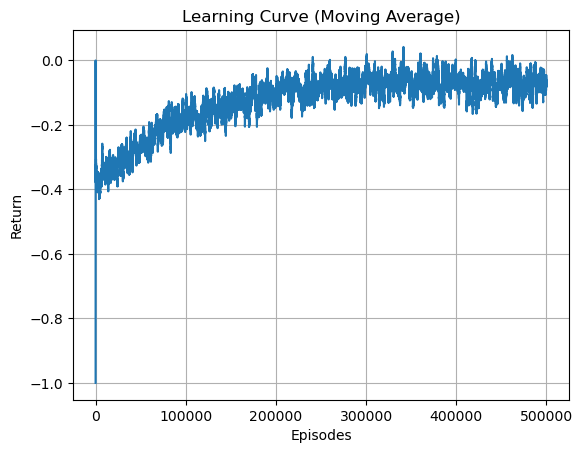

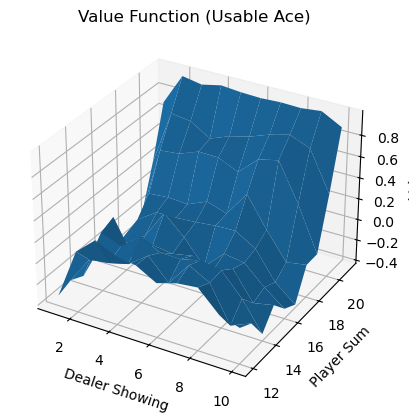

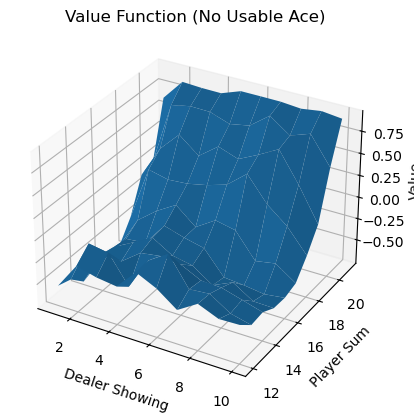

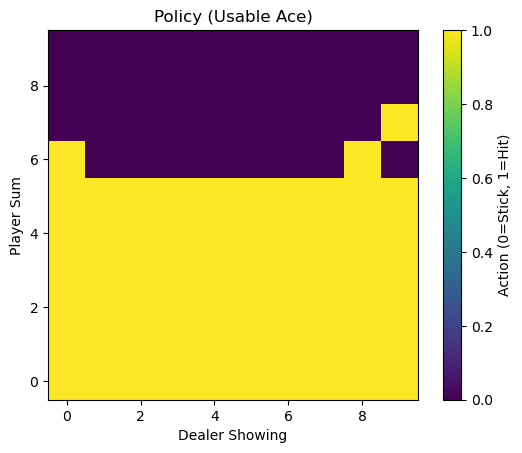

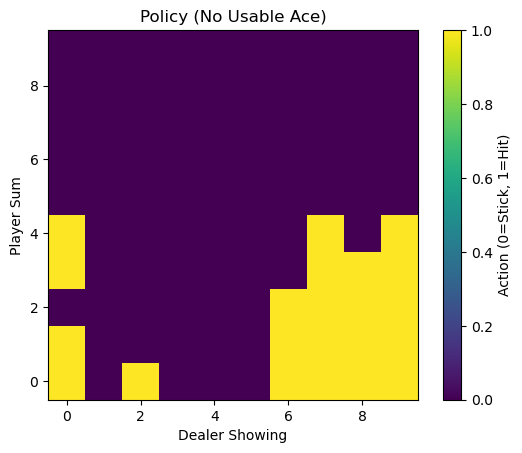

In [6]:
def main():
    env = gym.make("Blackjack-v1", sab=True)

    print("Training Version 2...")
    Q, returns, moving_avg = mc_control_v2(env)

    plot_learning(moving_avg)

    # Value functions
    p, d, V_ace = compute_value_function(Q, True)
    p, d, V_noace = compute_value_function(Q, False)

    plot_surface(p, d, V_ace, "Value Function (Usable Ace)")
    plot_surface(p, d, V_noace, "Value Function (No Usable Ace)")

    # Policies
    _, _, pol_ace = compute_policy(Q, True)
    _, _, pol_noace = compute_policy(Q, False)

    plot_policy(pol_ace, "Policy (Usable Ace)")
    plot_policy(pol_noace, "Policy (No Usable Ace)")


if __name__ == "__main__":
    main()